In [27]:
# Import standard libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Data Preprocessing Steps
* Clean the data, checking null values and duplicate values, some basics stastics

In [28]:
# Load the data set
data=pd.read_csv('/kaggle/input/customer-analytics-practice-dataset/Mall_Customers_Enhanced.csv')
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Age Group,Estimated Savings (k$),Credit Score,Loyalty Years,Preferred Category
0,1,Male,19,15,39,18-25,11.10,456,3,Budget
1,2,Male,21,15,81,18-25,6.90,300,6,Luxury
2,3,Female,20,16,6,18-25,15.36,594,2,Budget
3,4,Female,23,16,77,18-25,7.79,300,6,Luxury
4,5,Female,31,17,40,26-35,12.47,480,5,Budget


In [29]:
# Basic information about the all the information
def all_information(data):
    print(f'The shape of the data frame {data.shape}')
    print(f'Checking the null values in the data set {data.isna().sum()/len(data)*100}')
    data.info()
    data.dtypes
all_information(data)
    

The shape of the data frame (200, 10)
Checking the null values in the data set CustomerID                0.0
Gender                    0.0
Age                       0.0
Annual Income (k$)        0.0
Spending Score (1-100)    0.0
Age Group                 2.0
Estimated Savings (k$)    0.0
Credit Score              0.0
Loyalty Years             0.0
Preferred Category        0.0
dtype: float64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CustomerID              200 non-null    int64  
 1   Gender                  200 non-null    object 
 2   Age                     200 non-null    int64  
 3   Annual Income (k$)      200 non-null    int64  
 4   Spending Score (1-100)  200 non-null    int64  
 5   Age Group               196 non-null    object 
 6   Estimated Savings (k$)  200 non-null    float64
 7   Credit Score       

In [30]:
data.describe().style.background_gradient(cmap='flare_r')

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Estimated Savings (k$),Credit Score,Loyalty Years
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000,40.247950,743.680000,5.930000
std,57.879185,13.969007,26.264721,25.823522,21.333448,155.176727,1.570808
min,1.000000,18.000000,15.000000,1.000000,6.460000,300.000000,2.000000
25%,50.750000,28.750000,41.500000,34.750000,28.800000,697.000000,5.000000
50%,100.500000,36.000000,61.500000,50.000000,36.410000,833.000000,6.000000
75%,150.250000,49.000000,78.000000,73.000000,44.967500,850.000000,7.000000
max,200.000000,70.000000,137.000000,99.000000,120.560000,850.000000,9.000000


In [31]:
# fill the data mean values
data['Age Group']=data['Age Group'].fillna(value=data['Age'].mean())
data.isna().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
Age Group                 0
Estimated Savings (k$)    0
Credit Score              0
Loyalty Years             0
Preferred Category        0
dtype: int64

In [32]:
data.head(3)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Age Group,Estimated Savings (k$),Credit Score,Loyalty Years,Preferred Category
0,1,Male,19,15,39,18-25,11.10,456,3,Budget
1,2,Male,21,15,81,18-25,6.90,300,6,Luxury
2,3,Female,20,16,6,18-25,15.36,594,2,Budget


# Explore Data Analysis
* Visualise the Bar charts, Line charts, and boxplots.

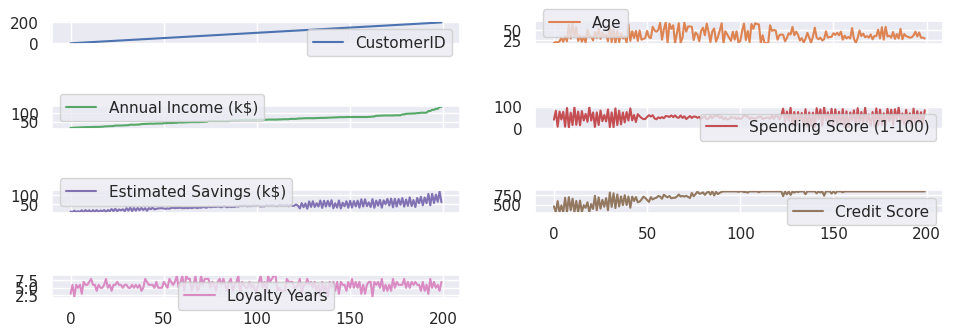

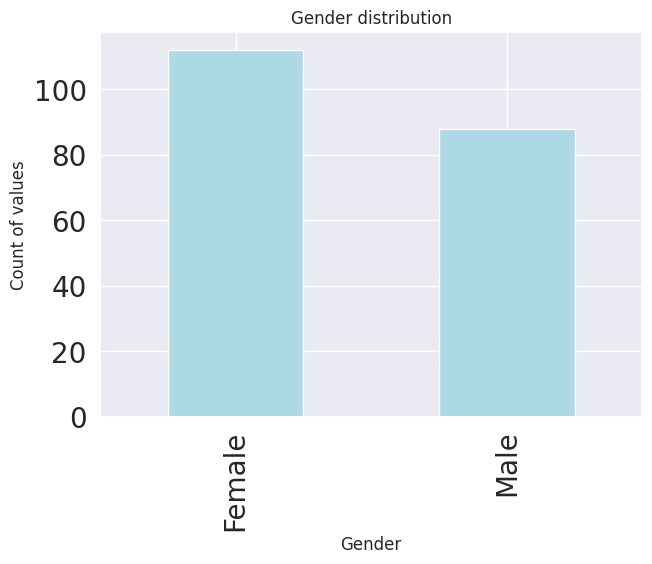

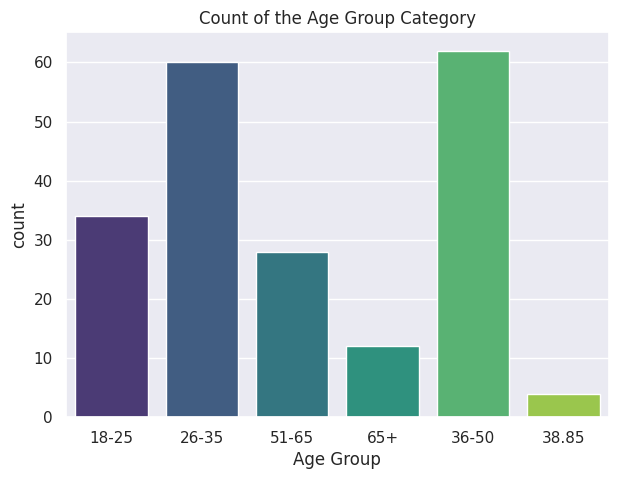

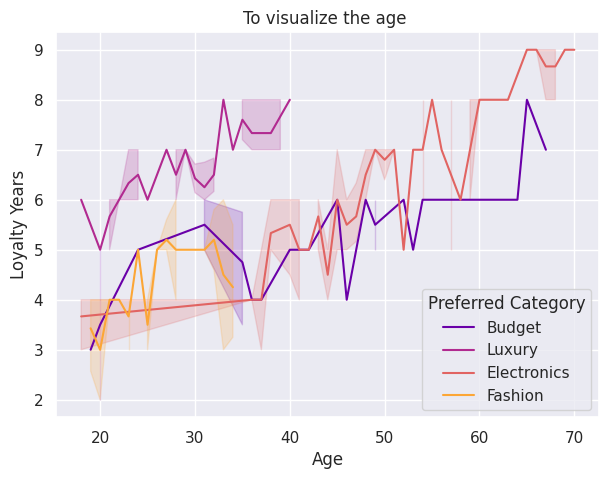

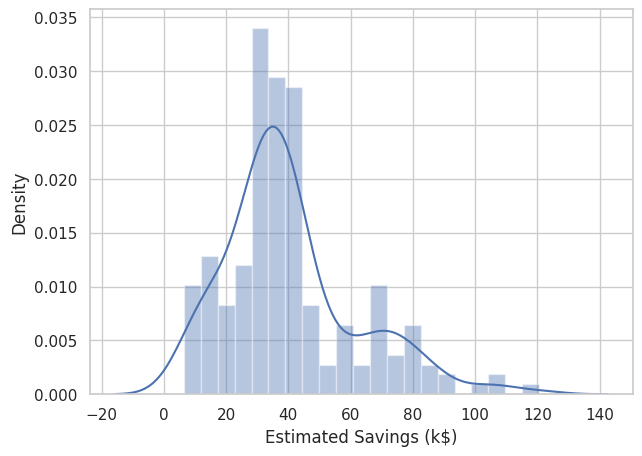

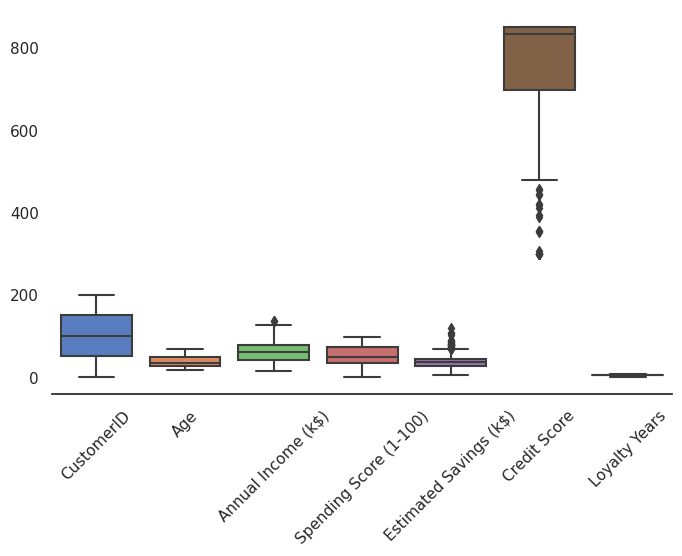

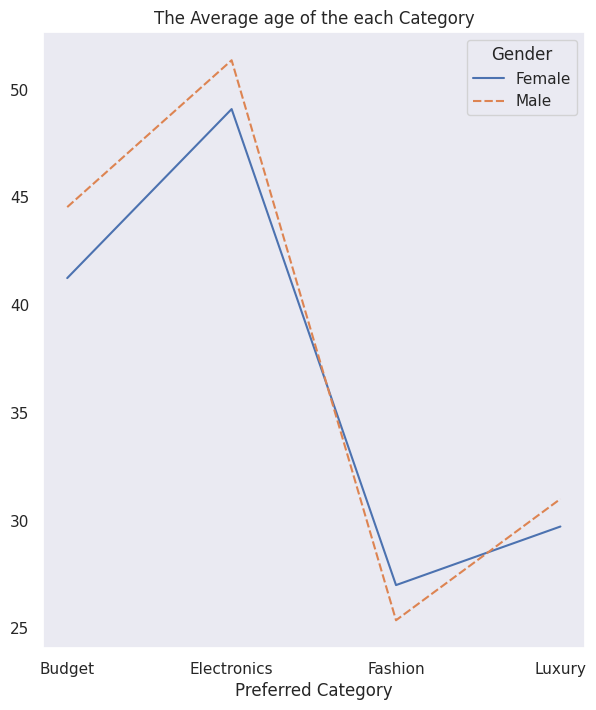

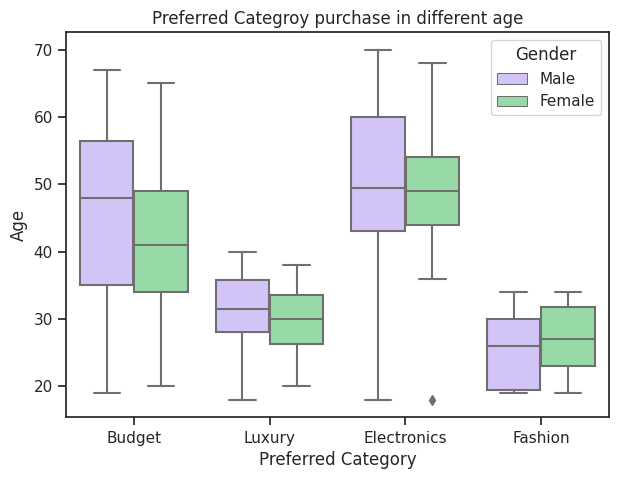

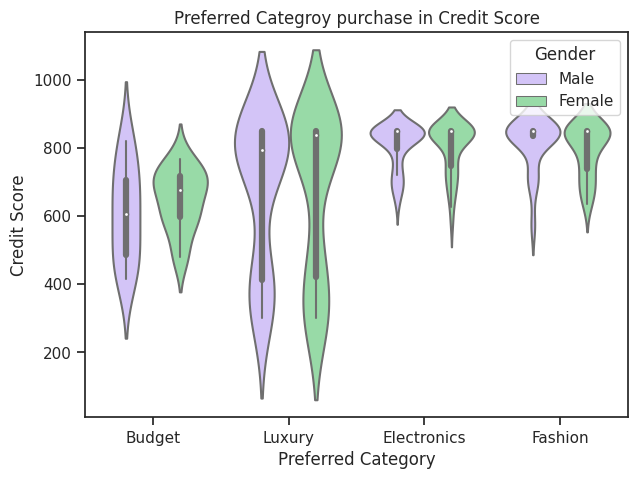

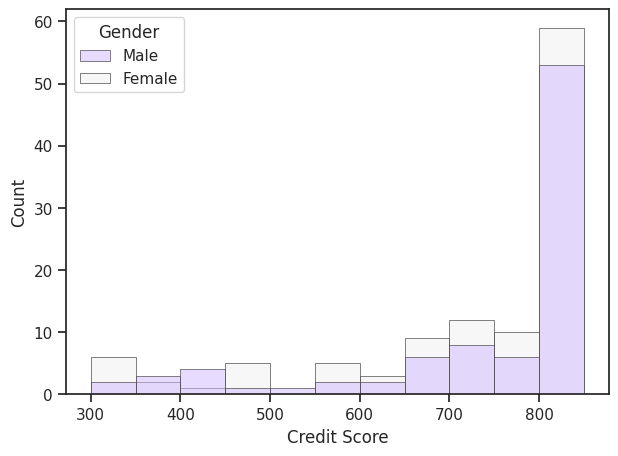

In [84]:
ax = data.plot(subplots=True, layout=(7,2), figsize=(10,6))
plt.tight_layout(pad=2.0)  # `pad` = gap around plots
plt.show()

# Gender distribution 
gender=data['Gender'].value_counts().sort_values(ascending=False)
plt.figure(figsize=(7,5))
gender.plot(kind='bar',fontsize=20,color='lightblue')
plt.title('Gender distribution')
plt.xlabel('Gender')
plt.ylabel('Count of values')

# Age Group
plt.figure(figsize=(7,5))
sns.countplot(data=data, x='Age Group', palette='viridis')
plt.title('Count of the Age Group Category')
plt.show()


# Lineplot
sns.set_theme(style="darkgrid")
plt.figure(figsize=(7,5))
sns.lineplot(data=data, x='Age',y='Loyalty Years',hue='Preferred Category',palette='plasma')
plt.title('To visualize the age ')
plt.show()

# Distribution of the Estimated Savings (k$) 
plt.figure(figsize=(7,5))
sns.set_theme(style='whitegrid')
sns.distplot(data['Estimated Savings (k$)'],kde=True)
plt.show()


# all the data 
plt.figure(figsize=(8,5))
sns.set_theme(style="white")
sns.boxplot(data=data, palette="muted")
sns.despine(left=True)
plt.xticks(rotation=45)
plt.show


# Find the average age of each category in gender wise
avg_age=data.pivot_table(index='Preferred Category',columns='Gender',values='Age',aggfunc='mean')
sns.set_theme(style="dark")
plt.figure(figsize=(7,8))
sns.lineplot(avg_age)
plt.title('The Average age of the each Category')
plt.show()

# Box plot
plt.figure(figsize=(7,5))
sns.set_theme(style="ticks", palette="pastel")
sns.boxplot(x='Preferred Category',y='Age',hue='Gender',data=data,palette=["m", "g"])
plt.title('Preferred Categroy purchase in different age')
plt.show()

# Violinplot 
plt.figure(figsize=(7,5))
sns.set_theme(style="ticks", palette="pastel")
sns.violinplot(x='Preferred Category',y='Credit Score',hue='Gender',data=data,palette=["m", "g"])
plt.title('Preferred Categroy purchase in Credit Score')
plt.show()



# Histogram distribution with credit Score
plt.figure(figsize=(7,5))
sns.histplot(data,x="Credit Score", hue="Gender",
    palette="light:m_r",
    edgecolor=".3",
    linewidth=.5)
plt.show()

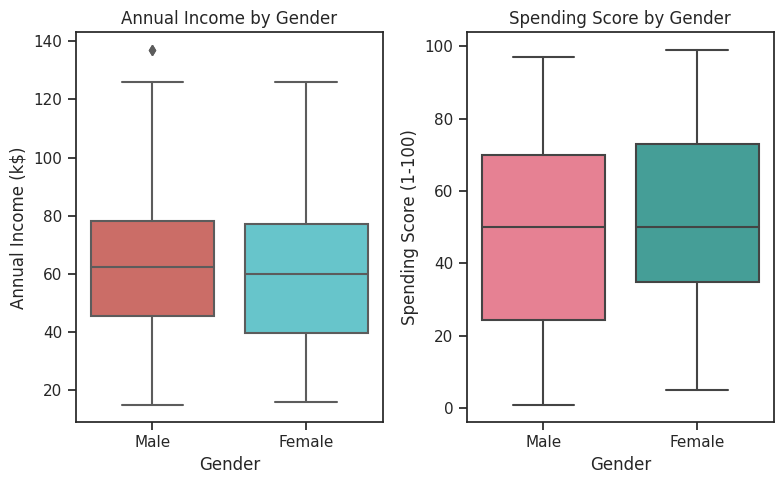

In [79]:
plt.figure(figsize=(8,5))
plt.subplot(1, 2, 1)
sns.boxplot(x='Gender', y='Annual Income (k$)', data=data,palette='hls')
plt.title('Annual Income by Gender')

plt.subplot(1, 2, 2)
sns.boxplot(x='Gender', y='Spending Score (1-100)', data=data,palette='husl')
plt.title('Spending Score by Gender')

plt.tight_layout()

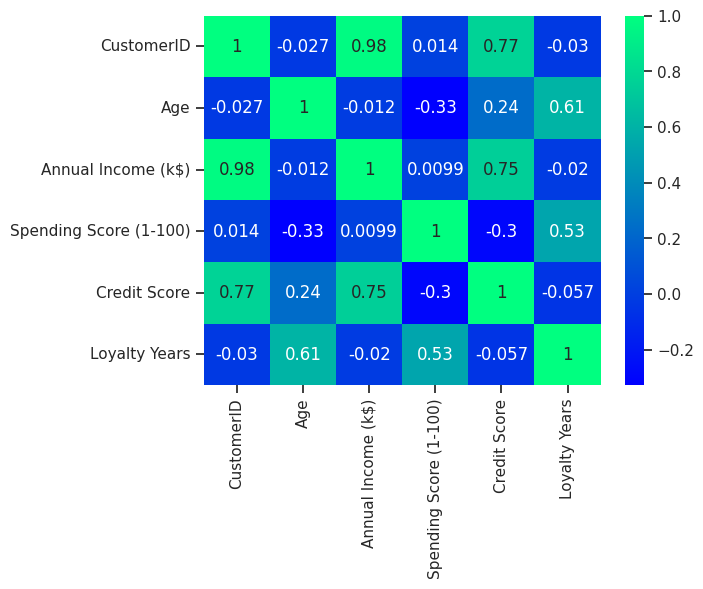

In [77]:
# Correlation Matrices
numerical=data.select_dtypes(include='int')
correlation=numerical.corr()
sns.heatmap(data=correlation,cmap='winter',annot=True,fmt='.2g')
plt.show()

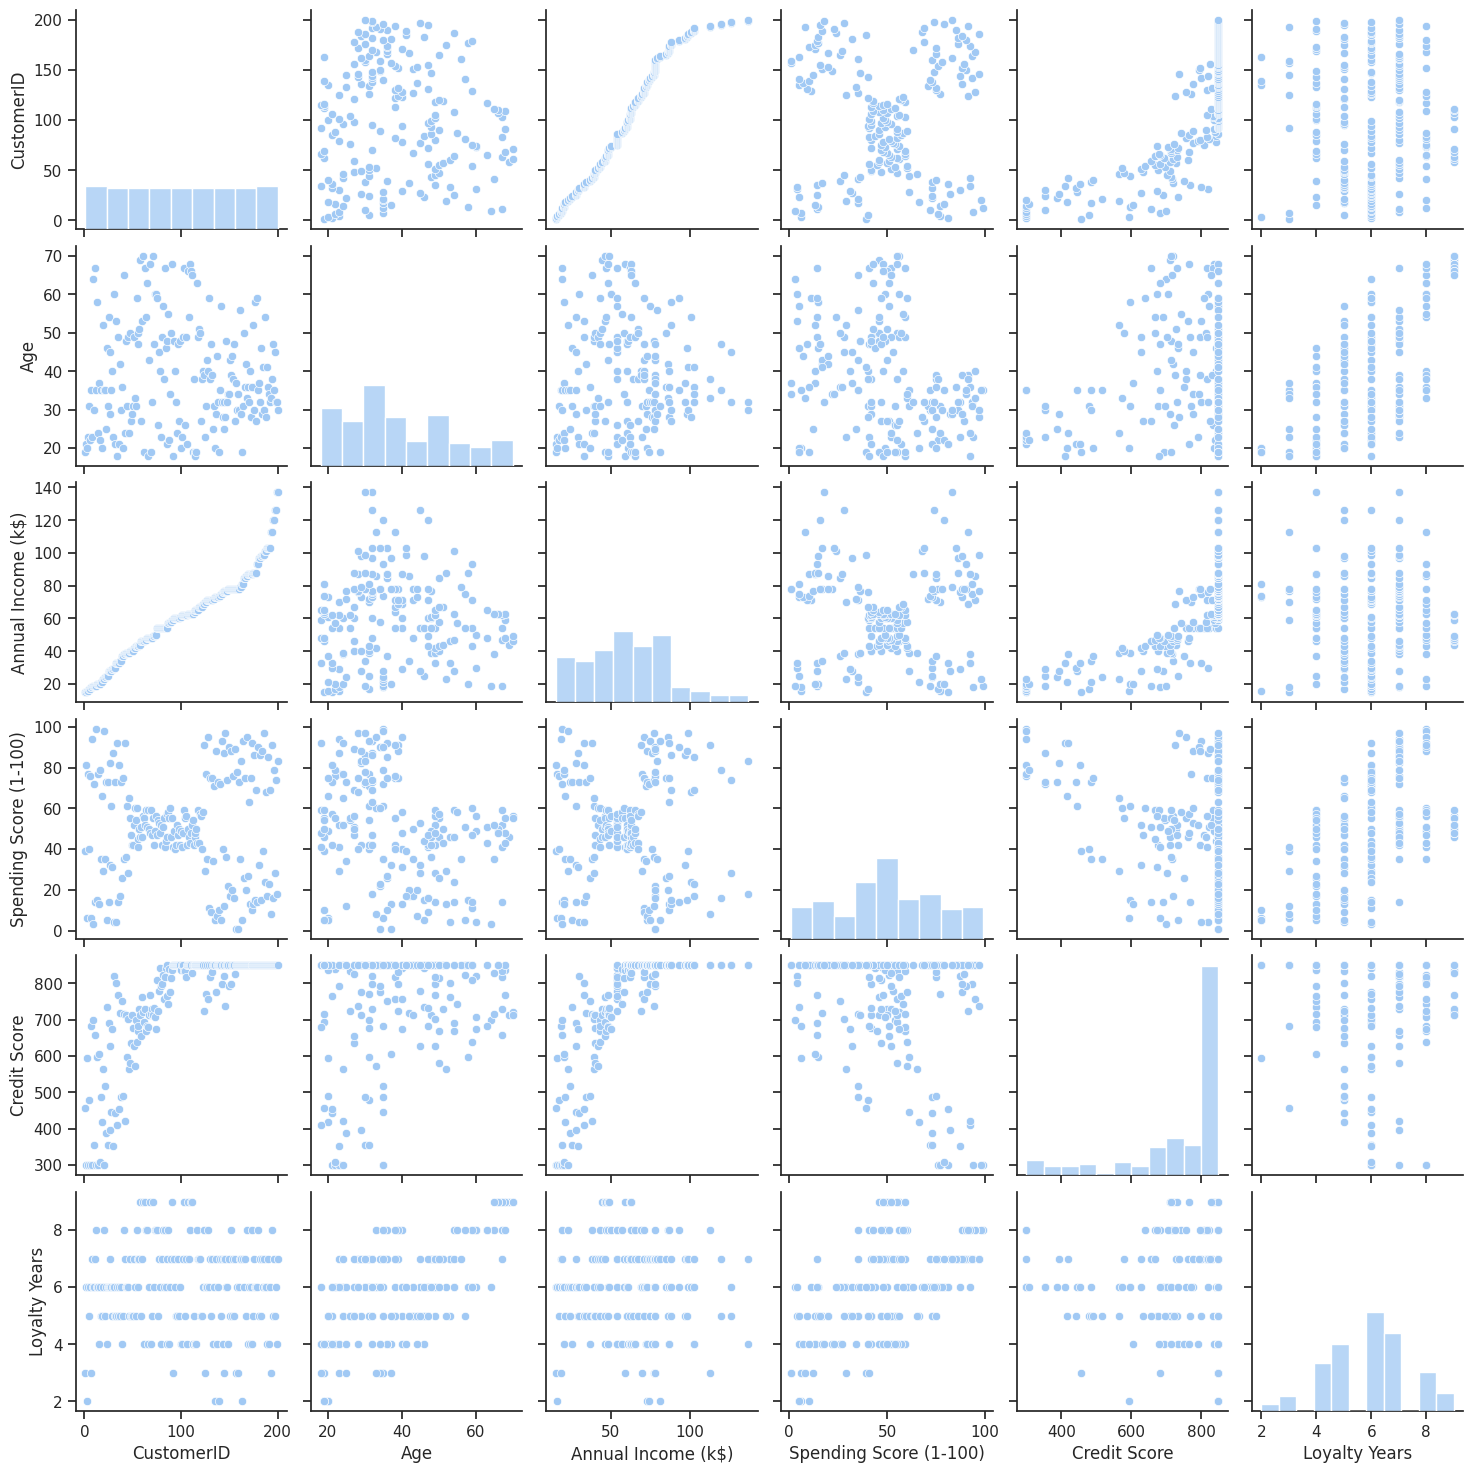

In [73]:

# Pirplot 
sns.pairplot(numerical)
plt.show()

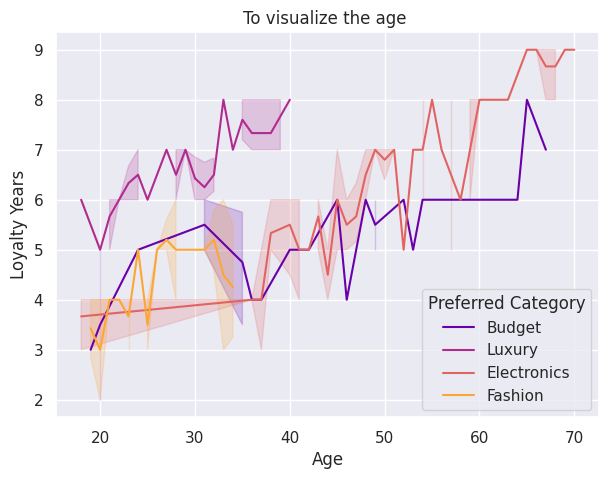

In [83]:
# Lineplot
sns.set_theme(style="darkgrid")
plt.figure(figsize=(7,5))
sns.lineplot(data=data, x='Age',y='Loyalty Years',hue='Preferred Category',palette='plasma')
plt.title('To visualize the age ')
plt.show()


In [65]:
average_creditscore=pd.DataFrame(data.groupby('Gender')['Credit Score'].mean().sort_values(ascending=False))
average_creditscore

,Credit Score
Gender,
Male,750.375000
Female,738.419643


In [72]:
average_category_credit=pd.DataFrame(data.groupby(['Preferred Category','Gender'])['Credit Score'].mean())
average_category_credit.unstack().style.background_gradient(cmap='Reds')